In [1]:
# feature learning + SHAP, R^2=0.032 means that features will explain little variance in wait time
# ED waittimes are largely operationally determined and race adds marginal predictive signal beyond clinical factors

In [2]:
import pandas as pd
df_model = pd.read_pickle('nhamcs_model.pkl')

In [3]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [4]:
features = ['RACERETH', 'IMMEDR', 'PAYTYPER', 'AGE', 'SEX', 'ARREMS', 'arrival_hour']
X = df_model[features].copy()

# Cast any categorical/object columns to int
for col in X.select_dtypes(include=['category', 'object']).columns:
    X[col] = X[col].astype(int)

print(X.dtypes)

RACERETH        int64
IMMEDR          int64
PAYTYPER        int64
AGE             int16
SEX              int8
ARREMS          int64
arrival_hour    Int64
dtype: object


/Users/amyyu/Desktop/Python_Projects/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 6376 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6376 when initializing the masker.


              precision    recall  f1-score   support

           0       0.53      0.58      0.55       797
           1       0.53      0.49      0.51       798

    accuracy                           0.53      1595
   macro avg       0.53      0.53      0.53      1595
weighted avg       0.53      0.53      0.53      1595

AGE             0.468619
arrival_hour    0.274611
IMMEDR          0.072548
PAYTYPER        0.070280
RACERETH        0.068158
SEX             0.025986
ARREMS          0.019798
dtype: float64


 99%|===================| 3161/3190 [01:20<00:00]        

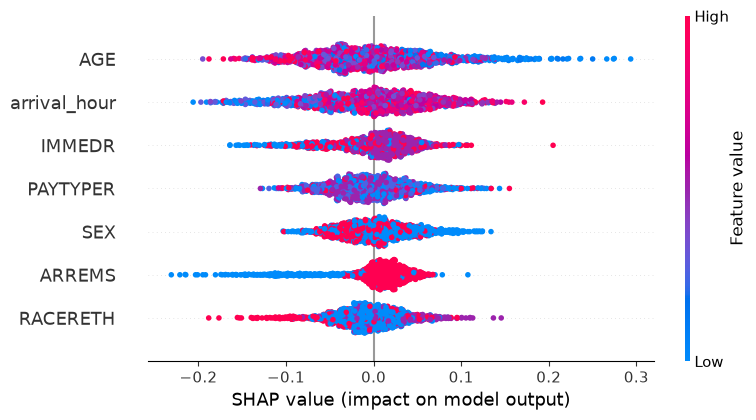

In [5]:
# LR framed as a classification problem, dichotimize wait time at the median (long vs. short wait) predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import shap

# Dichotomize outcome
median_wait = df_model['log_waittime'].median()
df_model['long_wait'] = (df_model['log_waittime'] > median_wait).astype(int)

# Features
features = ['RACERETH', 'IMMEDR', 'PAYTYPER', 'AGE', 'SEX', 'ARREMS', 'arrival_hour']
X = df_model[features].copy()
y = df_model['long_wait']

# Cast any categorical/object columns to int
for col in X.select_dtypes(include=['category', 'object']).columns:
    X[col] = X[col].astype(int)

X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

# SHAP (install: pip install shap)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values[:, :, 1], feature_names=features)


In [6]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else [v.shape for v in shap_values])

<class 'shap._explanation.Explanation'>
(1595, 7, 2)


In [7]:
print(shap.__version__)

0.52.0


  age_group   WAITTIME
0       0-5  36.459364
1      6-17  41.133646
2     18-35  34.667550
3     36-55  35.634647
4     56-75  34.556573
5       75+  29.872705


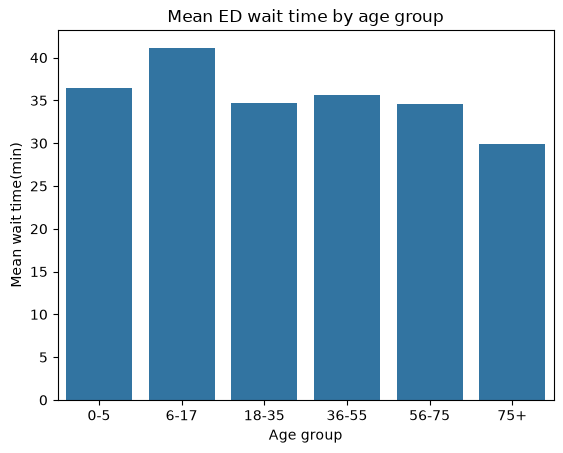

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns

df_model['age_group'] = pd.cut(df_model['AGE'],
                                bins=[0, 5, 17, 35, 55, 75, 100],
                                labels=['0-5', '6-17', '18-35', '36-55', '56-75', '75+'])

age_wait = df_model.groupby('age_group')['WAITTIME'].mean().reset_index()
print(age_wait)

sns.barplot(data=age_wait, x='age_group', y='WAITTIME')
plt.xlabel('Age group')
plt.ylabel('Mean wait time(min)')
plt.title('Mean ED wait time by age group')
plt.show()